In [1]:
import torch
import torch.nn as nn
import tiktoken as tk
from torch.utils.data import Dataset, DataLoader

In [2]:
!pip install gutenbergpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.5 MB/s eta 0:00:00
  Created wheel for httpsproxy-urllib2: filename=httpsproxy_urllib2-1.0-py3-none-any.whl size=29251 sha256=42e0cb1548c0c6b6bc6db95298e6ff5a1bd9235cdb66597d1d323c47f0b5f203
  Stored in directory: /root/.cache/pip/wheels/c6/c5/98/dd27835c8319362f1cef163409f43df38d54f084500fad428c
Successfully built httpsproxy-urllib2


In [3]:
import gutenbergpy.textget
import random
import math

also implement to see how much each embedding query and key is rotated from their token embeddings

and test whether two words with same number of words in between give similar dot product at different time steps

In [4]:
def rotary_emb(head_dim, context_length, device, theta_base=10000):
  assert head_dim % 2 == 0, "head_dim should be divisible by 2"

  freq = 1 / theta_base ** (torch.arange(0, head_dim, 2, device=device)[:(head_dim//2)].float()/head_dim)
  positions = torch.arange(0, context_length, device=device) # (context_length,)
  angles = positions.unsqueeze(1) * freq.unsqueeze(0) # (context_length, head_dim//2)
  angles = torch.cat([angles, angles], dim=1) # (context_length, head_dim)

  cos = torch.cos(angles)
  sin = torch.sin(angles)

  return cos, sin

def apply_rotation(query, key, cos, sin):
  # query and key shape (batch_size, num_heads, seq_len, head_dim)
  batch_size, num_heads, seq_len, head_dim = query.shape
  assert head_dim % 2 == 0, "head_dim should be divisible by 2"
  cos = cos[:seq_len,:]
  sin = sin[:seq_len,:]
  cos = cos.unsqueeze(0).unsqueeze(0)
  sin = sin.unsqueeze(0).unsqueeze(0)
  cos = cos.view(1, 1, seq_len, 2, head_dim//2).transpose(-2, -1).flatten(start_dim=-2)
  sin = sin.view(1, 1, seq_len, 2, head_dim//2).transpose(-2, -1).flatten(start_dim=-2)

  q1 = query[..., ::2]
  q2 = query[..., 1::2]
  query_2 = torch.stack([-q2, q1], dim=-1).flatten(start_dim=-2)
  rotated_query = query * cos + query_2 * sin

  k1 = key[..., ::2]
  k2 = key[..., 1::2]
  key_2 = torch.stack([-k2, k1], dim=-1).flatten(start_dim=-2)
  rotated_key = key * cos + key_2 * sin

  return rotated_query, rotated_key

In [5]:
GPT_CONFIG_124M = {
    'emb_size':768,
    'context_length':4096,
    'vocab_size':50257,
    'num_heads':12,
    'num_layers':12,
    'drop_rate':0.1,
    'qkv_bias':False,
}

In [6]:
#lets implement compact class for normalization
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [7]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

In [8]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

In [9]:
def generate_text_tokens(model, inp_tokens, max_tokens, context_size):
  for _ in range(max_tokens):
    cropped_tokens = inp_tokens[:,-context_size:]
    with torch.no_grad():
      logits = model(cropped_tokens)

    logits = logits[:,-1,:]
    prob = torch.softmax(logits, dim=-1)
    token_id = torch.argmax(prob, dim=-1, keepdim=True)
    inp_tokens = torch.cat((inp_tokens, token_id), dim=1)

  return inp_tokens

In [10]:
tokenizer = tk.get_encoding("gpt2")

In [11]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text)
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(tokens, tokenizer):
  token_list = tokens.squeeze(0).tolist()
  decoded = tokenizer.decode(token_list)
  return decoded

In [12]:
class GPTDataset(Dataset):
  def __init__(self, text, tokenizer, max_length, stride):
    self.inputs = []
    self.targets = []

    encoded_text = tokenizer.encode(text)

    for i in range(0,len(encoded_text) - max_length, stride):
      input = encoded_text[i:i+max_length]
      target = encoded_text[i+1:i+max_length+1]

      self.inputs.append(torch.tensor(input))
      self.targets.append(torch.tensor(target))

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, index):
    return self.inputs[index], self.targets[index]

In [13]:
def download_dataset(n_books=100):
    # IDs are roughly between 1 and 70,000
    # We'll pick random IDs; note: not all IDs exist or are English
    book_ids = random.sample(range(1, 60000), n_books * 2)
    downloaded_texts = []

    for b_id in book_ids:
        try:
            # 1. Get raw text
            raw_text = gutenbergpy.textget.get_text_by_id(b_id)
            # 2. Strip Gutenberg headers/footers (CRITICAL for LLMs)
            clean_text = gutenbergpy.textget.strip_headers(raw_text)

            downloaded_texts.append(clean_text.decode('utf-8'))
            print(f"Downloaded book {b_id}")

            if len(downloaded_texts) >= n_books:
                break
        except:
            continue # Skip IDs that aren't available in text format

    return downloaded_texts

In [14]:
random.seed(10)
texts = download_dataset(n_books=15)
shuffled_texts = random.sample(texts, len(texts))
train_texts_list = shuffled_texts[:13]
val_texts_list = shuffled_texts[13:]

train_texts = tokenizer.decode([tokenizer.eot_token])[0].join(train_texts_list)
val_texts = tokenizer.decode([tokenizer.eot_token])[0].join(val_texts_list)

Downloaded book 37448
Downloaded book 2136
Downloaded book 28108
Downloaded book 31626
Downloaded book 37886
Downloaded book 973
Downloaded book 13507
Downloaded book 30316
Downloaded book 53302
Downloaded book 32198
Downloaded book 53975
Downloaded book 18188
Downloaded book 42826
Downloaded book 53125
Downloaded book 10501


In [15]:
print(texts[0])











[Illustration: BRINKER BRINKER in footprints]




     _A man may be a scoundrel, a crook, a high-phased confidence man,
     and still work toward a great dream which will be worth far more
     than the momentary damage his swindles cost._




_Comet's Burial_

_by_ RAYMOND Z. GALLUN


Outside Tycho Station on the Moon, Jess Brinker showed Arne Copeland the
odd footprints made in the dust by explorers from Mars, fifty million
years ago. A man-made cover of clear plastic now kept them from being
trampled.

"Who hasn't heard about such prints?" Copeland growled laconically.
"There's no air or weather here to rub them out--even in eternity.
Thanks for showing a fresh-arrived greenhorn around..."

Copeland was nineteen, tough, willing to learn, but wary. His wide mouth
was usually sullen, his grey eyes a little narrowed in a face that
didn't have to be so grim. Back in Iowa he had a girl. Frances. But love
had to wait, for he needed the Moon the way Peary had once needed the
No

In [16]:
print(f"Tokens in train set: {len(tokenizer.encode(train_texts))}")
print(f"Tokens in val set: {len(tokenizer.encode(val_texts))}")

Tokens in train set: 768464
Tokens in val set: 81370


In [17]:
train_dataset = GPTDataset(train_texts, tokenizer, max_length=256, stride=256)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True, num_workers=0)

In [18]:
val_dataset1 = GPTDataset(val_texts, tokenizer, max_length=256, stride=256)
val_loader1 = DataLoader(val_dataset1, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

val_dataset2 = GPTDataset(val_texts, tokenizer, max_length=512, stride=512)
val_loader2 = DataLoader(val_dataset2, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

val_dataset3 = GPTDataset(val_texts, tokenizer, max_length=1024, stride=1024)
val_loader3 = DataLoader(val_dataset3, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

val_dataset4 = GPTDataset(val_texts, tokenizer, max_length=1536, stride=1536)
val_loader4 = DataLoader(val_dataset4, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

val_dataset5 = GPTDataset(val_texts, tokenizer, max_length=2048, stride=2048)
val_loader5 = DataLoader(val_dataset5, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

val_dataset6 = GPTDataset(val_texts, tokenizer, max_length=4096, stride=4096)
val_loader6 = DataLoader(val_dataset6, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

In [19]:
# just to get the idea of tokens on which earlier gpt2 was trained
file_path = "/content/drive/My Drive/LLM/Data/the-verdict.txt"
with open(file_path,"r",encoding="utf-8") as f:
  raw_text = f.read()

print(f"Tokens used in pervious training: {len(tokenizer.encode(raw_text))}")

Tokens used in pervious training: 5145


In [20]:
for x,y in train_loader:
  print(x.shape, y.shape)
  break

torch.Size([2, 256]) torch.Size([2, 256])


In [21]:
for x,y in val_loader1:
  print(x.shape, y.shape)
  break

torch.Size([2, 256]) torch.Size([2, 256])


In [22]:
for x,y in val_loader2:
  print(x.shape, y.shape)
  break

torch.Size([2, 512]) torch.Size([2, 512])


In [23]:
for x,y in val_loader3:
  print(x.shape, y.shape)
  break

torch.Size([2, 1024]) torch.Size([2, 1024])


In [24]:
def ce_batch_loss_calc(input_batch, target_batch, model, device):
  """
  ARGS
  input_batch: torch.tensor 2-D
  target_batch: torch.tensor 2-D
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'

  calculates cross-entropy loss for a batch
  """
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits_batch = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits_batch.flatten(0, 1), target_batch.flatten())

  return loss

In [25]:
def calc_loss_dataloader(loader, model, device, num_batches=None):
  """
  ARGS
  loader: dataloader
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'
  num_batches: integer

  calculates mean cross entropy loss across all the batches of the dataloader
  """
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device)
      total_loss += loss
    else:
      break

  return total_loss/num_batches

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [27]:
def train_model_simple(model, train_loader, val_loader, device, optimizer, epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_loss_arr, val_loss_arr, track_tokens_seen = [], [], []
  global_step, tokens_seen = -1, 0

  for epoch in range(epochs):
    model.train()
    for x, y in train_loader:
      model.zero_grad()
      train_loss = ce_batch_loss_calc(x, y, model, device)
      train_loss.backward()
      optimizer.step()
      tokens_seen += x.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_loss_arr.append(train_loss)
        val_loss_arr.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Train loss after epoch {epoch} (Step: {global_step}): {train_loss:.3f}')
        print(f'Val loss after epoch {epoch} (Step: {global_step}): {val_loss:.3f}')
        print(f'Number of tokens seen after epoch {epoch} (Step: {global_step})')

    generate_and_print_sample(model, start_context, tokenizer, device)

  return train_loss_arr, val_loss_arr, track_tokens_seen

In [28]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter=None):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, eval_iter)
    val_loss = calc_loss_dataloader(val_loader, model, device, eval_iter)
  model.train()

  return train_loss, val_loss

In [29]:
def generate_and_print_sample(model, start_context, tokenizer, device):
  model.eval()
  context_size = model.trf_blocks[0].mha.mask.shape[0] ##model.pos_emb.shape[0]
  encoded_text = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    op_tokens = generate_text_tokens(model, encoded_text, max_tokens=50, context_size=context_size)
  decoded_text = token_ids_to_text(op_tokens, tokenizer)

  print(decoded_text.replace('\n',' '))
  model.train()

In [30]:
def calculate_perplexity(model, loader, device):
  model.eval()
  with torch.no_grad():
    val_loss = calc_loss_dataloader(loader, model, device)

  return math.exp(val_loss)

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_results(train_losses, val_losses, tokens_seen,title):
    """
    Plots training and validation losses against the number of tokens processed.

    Args:
        train_losses (list): List of training loss values (usually recorded per step).
        val_losses (list): List of validation loss values (recorded periodically).
        tokens_seen (list): Cumulative count of tokens the model has seen at each step.
    """
    # Create the figure
    plt.figure(figsize=(6, 4))

    train_losses = [t_loss.clone().cpu().numpy() for t_loss in train_losses]
    val_losses = [v_loss.clone().cpu().numpy() for v_loss in val_losses]

    # Calculate step indices for val_losses
    # (Assuming val_loss is calculated less frequently than train_loss)
    val_step_interval = len(train_losses) // len(val_losses)
    val_tokens = tokens_seen[::val_step_interval][:len(val_losses)]

    # Plot Training Loss
    plt.plot(tokens_seen, train_losses, label='Train Loss', color='skyblue', alpha=0.5)

    # Plot Validation Loss (usually a smoother line)
    plt.plot(val_tokens, val_losses, label='Val Loss', color='darkblue')

    # Formatting
    plt.title(title, fontsize=14)
    plt.xlabel('Tokens Seen', fontsize=12)
    plt.ylabel('Cross Entropy Loss', fontsize=12)

    # Use scientific notation for tokens if they are very large
    plt.ticklabel_format(style='plain', axis='x')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Optional: Log scale for loss if it starts very high
    # plt.yscale('log')

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# tokens = [1024, 2048, 3072, 4096, 5120, 6144]
# t_loss = [4.5, 3.8, 3.2, 2.9, 2.7, 2.5]
# v_loss = [4.6, 3.0, 2.6] # Val evaluated every 2 steps
# plot_training_results(t_loss, v_loss, tokens)

# **RoPE**

In [32]:
class MultiHeadAttentionRoPE(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    # RoPE
    cos, sin = rotary_emb(self.head_dim, num_tokens, device=x.device)
    queries, keys = apply_rotation(queries, keys, cos, sin)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [33]:
class TransformerBlockRoPE(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.mha = MultiHeadAttentionRoPE(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [34]:
class GPTModelRoPE(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['vocab_size'], cfg['emb_size'])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlockRoPE(cfg) for _ in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['vocab_size'], bias=False)

  def forward(self, inp_tokens):
    batch_size, num_tokens = inp_tokens.shape
    token_emb = self.token_emb_layer(inp_tokens)

    x = token_emb
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

In [35]:
import time

torch.manual_seed(123)
model1 = GPTModelRoPE(GPT_CONFIG_124M)
model1.to(device)
optimizer = torch.optim.AdamW(model1.parameters(), lr=0.0004, weight_decay=0.1)

t1 = time.time()
train_losses, val_losses, tokens_seen = train_model_simple(model1, train_loader, val_loader1, device, optimizer, epochs=2, eval_freq=5, eval_iter=5, start_context='Every effort moves you', tokenizer=tokenizer)
t2 = time.time()

print(f"Training time: {t2-t1}s")

Train loss after epoch 0 (Step: 0): 9.846
Val loss after epoch 0 (Step: 0): 9.182
Number of tokens seen after epoch 0 (Step: 0)
Train loss after epoch 0 (Step: 5): 8.991
Val loss after epoch 0 (Step: 5): 8.785
Number of tokens seen after epoch 0 (Step: 5)
Train loss after epoch 0 (Step: 10): 7.969
Val loss after epoch 0 (Step: 10): 8.361
Number of tokens seen after epoch 0 (Step: 10)
Train loss after epoch 0 (Step: 15): 7.711
Val loss after epoch 0 (Step: 15): 7.810
Number of tokens seen after epoch 0 (Step: 15)
Train loss after epoch 0 (Step: 20): 7.412
Val loss after epoch 0 (Step: 20): 7.561
Number of tokens seen after epoch 0 (Step: 20)
Train loss after epoch 0 (Step: 25): 7.521
Val loss after epoch 0 (Step: 25): 6.991
Number of tokens seen after epoch 0 (Step: 25)
Train loss after epoch 0 (Step: 30): 7.711
Val loss after epoch 0 (Step: 30): 6.818
Number of tokens seen after epoch 0 (Step: 30)
Train loss after epoch 0 (Step: 35): 7.085
Val loss after epoch 0 (Step: 35): 6.960
Numbe

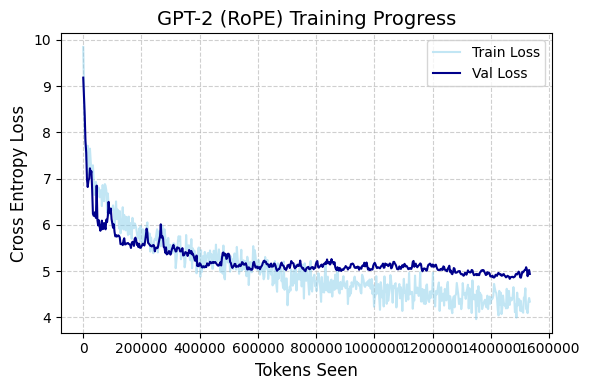

In [36]:
plot_training_results(train_losses, val_losses, tokens_seen, 'GPT-2 (RoPE) Training Progress')

In [37]:
perplexity_256_rope = calculate_perplexity(model1, val_loader1, device)
perplexity_512_rope = calculate_perplexity(model1, val_loader2, device)
perplexity_1024_rope = calculate_perplexity(model1, val_loader3, device)
perplexity_1536_rope = calculate_perplexity(model1, val_loader4, device)
perplexity_2048_rope = calculate_perplexity(model1, val_loader5, device)
perplexity_4096_rope = calculate_perplexity(model1, val_loader6, device)

print(f"RoPE Perplexity at 256: {perplexity_256_rope:.3f}")
print(f"RoPE Perplexity at 512: {perplexity_512_rope:.3f}")
print(f"RoPE Perplexity at 1024: {perplexity_1024_rope:.3f}")
print(f"RoPE Perplexity at 1536: {perplexity_1536_rope:.3f}")
print(f"RoPE Perplexity at 2048: {perplexity_2048_rope:.3f}")
print(f"RoPE Perplexity at 4096: {perplexity_4096_rope:.3f}")

RoPE Perplexity at 256: 218.529
RoPE Perplexity at 512: 227.305
RoPE Perplexity at 1024: 242.533
RoPE Perplexity at 1536: 252.937
RoPE Perplexity at 2048: 255.161
RoPE Perplexity at 4096: 265.132


In [38]:
rope_perplexities = [perplexity_256_rope, perplexity_512_rope, perplexity_1024_rope, perplexity_1536_rope, perplexity_2048_rope, perplexity_4096_rope]

# **Absolute Embeddings**

In [39]:
class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [40]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [41]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['vocab_size'], bias=False)

  def forward(self, inp_tokens):
    batch_size, num_tokens = inp_tokens.shape
    token_emb = self.token_emb_layer(inp_tokens)
    pos_emb = self.pos_emb_layer(
        torch.arange(num_tokens, device=inp_tokens.device)
    )
    x = token_emb + pos_emb
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

In [42]:
import time

torch.manual_seed(123)
model2 = GPTModel(GPT_CONFIG_124M)
model2.to(device)
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=0.0004, weight_decay=0.1)

t3 = time.time()
train_losses2, val_losses2, tokens_seen2 = train_model_simple(model2, train_loader, val_loader1, device, optimizer2, epochs=2, eval_freq=5, eval_iter=5, start_context='Every effort moves you', tokenizer=tokenizer)
t4 = time.time()

print(f"Training time: {t4-t3}s")

Train loss after epoch 0 (Step: 0): 10.188
Val loss after epoch 0 (Step: 0): 7.927
Number of tokens seen after epoch 0 (Step: 0)
Train loss after epoch 0 (Step: 5): 8.734
Val loss after epoch 0 (Step: 5): 8.159
Number of tokens seen after epoch 0 (Step: 5)
Train loss after epoch 0 (Step: 10): 7.995
Val loss after epoch 0 (Step: 10): 7.382
Number of tokens seen after epoch 0 (Step: 10)
Train loss after epoch 0 (Step: 15): 7.191
Val loss after epoch 0 (Step: 15): 7.115
Number of tokens seen after epoch 0 (Step: 15)
Train loss after epoch 0 (Step: 20): 7.512
Val loss after epoch 0 (Step: 20): 7.202
Number of tokens seen after epoch 0 (Step: 20)
Train loss after epoch 0 (Step: 25): 8.004
Val loss after epoch 0 (Step: 25): 7.457
Number of tokens seen after epoch 0 (Step: 25)
Train loss after epoch 0 (Step: 30): 7.140
Val loss after epoch 0 (Step: 30): 6.931
Number of tokens seen after epoch 0 (Step: 30)
Train loss after epoch 0 (Step: 35): 7.528
Val loss after epoch 0 (Step: 35): 6.789
Numb

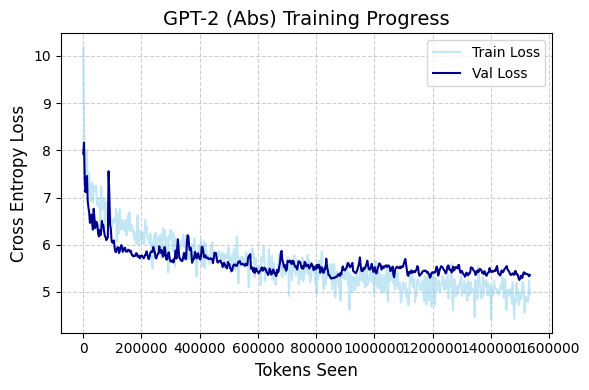

In [43]:
plot_training_results(train_losses2, val_losses2, tokens_seen2, 'GPT-2 (Abs) Training Progress')

In [44]:
perplexity_256_abs = calculate_perplexity(model2, val_loader1, device)
perplexity_512_abs = calculate_perplexity(model2, val_loader2, device)
perplexity_1024_abs = calculate_perplexity(model2, val_loader3, device)
perplexity_1536_abs = calculate_perplexity(model2, val_loader4, device)
perplexity_2048_abs = calculate_perplexity(model2, val_loader5, device)
perplexity_4096_abs = calculate_perplexity(model2, val_loader6, device)

print(f"Abs Perplexity at 256: {perplexity_256_abs:.3f}")
print(f"Abs Perplexity at 512: {perplexity_512_abs:.3f}")
print(f"Abs Perplexity at 1024: {perplexity_1024_abs:.3f}")
print(f"Abs Perplexity at 1536: {perplexity_1536_abs:.3f}")
print(f"Abs Perplexity at 2048: {perplexity_2048_abs:.3f}")
print(f"Abs Perplexity at 4096: {perplexity_4096_abs:.3f}")

Abs Perplexity at 256: 335.048
Abs Perplexity at 512: 348.660
Abs Perplexity at 1024: 358.215
Abs Perplexity at 1536: 365.744
Abs Perplexity at 2048: 364.280
Abs Perplexity at 4096: 366.783


In [48]:
abs_perplexities = [perplexity_256_abs, perplexity_512_abs, perplexity_1024_abs, perplexity_1536_abs, perplexity_2048_abs, perplexity_4096_abs]

# **Comparison**

In [45]:
context_lengths = [256, 512, 1024, 1536, 2048, 4096]

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ppl_comparison(ppl_model1, ppl_model2, context_lengths, labels=["Absolute", "RoPE"]):
    x = np.arange(len(context_lengths))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))

    # Simple bars
    ax.bar(x - width/2, ppl_model1, width, label=labels[0], color='salmon')
    ax.bar(x + width/2, ppl_model2, width, label=labels[1], color='skyblue')

    # Basic formatting
    ax.set_ylabel('Perplexity')
    ax.set_xlabel('Context Length')
    ax.set_xticks(x)
    ax.set_xticklabels(context_lengths)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Example usage:
# plot_ppl_comparison([15.2, 50.4, 120.1], [15.4, 16.8, 19.5], [512, 1024, 2048])

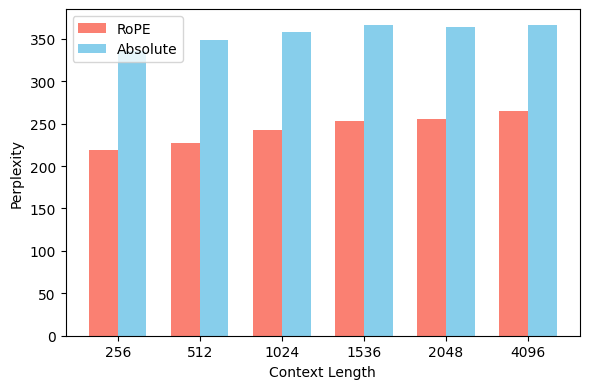

In [49]:
plot_ppl_comparison(rope_perplexities, abs_perplexities, context_lengths, labels=["RoPE", "Absolute"])

set the context length to 2048 or 4096 and train both models on 256 seq len and benchmark their perplexities till 2048 or 4096 context lens, and see how the perplexity is increasing